# Hybrid Prophet + GRU Pipeline

Two-stage workflow:

1. **Section 1 — Training** fits Prophet residuals, trains the GRU, and saves artifacts.
2. **Section 2 — Evaluation** loads saved artifacts and runs inference only (no GRU retraining).

Evaluation philosophy:

- **Primary evaluation (Day 1):** 96-step holdout forecast — reported in `evaluation_df` and `evaluation_summary`.
- **Supplementary evaluation (Day 2):** recursive 96-step extension using predicted Day 1 residuals — demo analysis only, not aggregated.

Input window:

- `INPUT_WINDOW` controls the GRU residual context length (96 or 288 timesteps).
- Production default remains **288** until the H1.2 ablation selects a final window.
- Run `scripts/run_hybrid_input_window_ablation.py` to compare both settings.

Set `RUN_TRAINING = False` in the configuration cell to skip training and evaluate a saved model.


## Shared Configuration


In [129]:
import importlib
import pandas as pd
import numpy as np
import pickle
import sys
import os

import matplotlib.pyplot as plt

from prophet import Prophet

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    GRU,
    Dense,
    Dropout,
)
from tensorflow.keras.callbacks import EarlyStopping

sys.path.append(
    os.path.abspath("..")
)

# Reload utils after code changes (avoids stale Jupyter module cache).
import utils.hybrid_config as hybrid_config
import utils.hybrid_training as hybrid_training
import utils.hybrid_artifacts as hybrid_artifacts
import utils.hybrid_evaluation as hybrid_evaluation
importlib.reload(hybrid_config)
importlib.reload(hybrid_training)
importlib.reload(hybrid_artifacts)
importlib.reload(hybrid_evaluation)

from utils.hybrid_config import (
    DAY1_HORIZON,
    DEFAULT_INPUT_WINDOW,
    FORECAST_HORIZON,
)
from utils.sequence_utils import create_residual_sequences
from utils.hybrid_training import (
    build_hybrid_gru_model,
    generate_prophet_residuals,
)
from utils.hybrid_artifacts import (
    save_hybrid_artifacts,
    load_hybrid_artifacts,
)
from utils.hybrid_evaluation import (
    compute_day1_mape,
    evaluate_selected_containers,
    summarize_evaluation_metrics,
)

# GRU residual input context (see utils/hybrid_config.py).
INPUT_WINDOW = DEFAULT_INPUT_WINDOW

# Set False to skip Section 1 and load saved artifacts for evaluation only.
RUN_TRAINING = False

MODEL_PATH = "../models/hybrid_gru.keras"
RESIDUAL_STATS_PATH = "../models/residual_stats.pkl"


## Shared Data Loading


In [130]:
train_df = pd.read_parquet(
    "../data/train_df.parquet"
)

val_df = pd.read_parquet(
    "../data/val_df.parquet"
)

with open("../data/scalers.pkl", "rb") as f:
    scalers = pickle.load(f)

selected_containers = np.load(
    "../data/selected_containers.npy",
    allow_pickle=True,
)
print(selected_containers)

global_train = train_df[
    train_df["container_id"]
    .isin(selected_containers)
].copy()

global_val = val_df[
    val_df["container_id"]
    .isin(selected_containers)
].copy()


Task was destroyed but it is pending!
task: <Task pending name='Task-767' coro=<_async_in_context.<locals>.run_in_context() done, defined at /Users/lehaan/Desktop/FYP_Long_Term/tf_metal_env/lib/python3.11/site-packages/ipykernel/utils.py:57> wait_for=<Task pending name='Task-768' coro=<Kernel.shell_main() running at /Users/lehaan/Desktop/FYP_Long_Term/tf_metal_env/lib/python3.11/site-packages/ipykernel/kernelbase.py:597> cb=[Task.task_wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at /Users/lehaan/Desktop/FYP_Long_Term/tf_metal_env/lib/python3.11/site-packages/zmq/eventloop/zmqstream.py:563]>
/var/folders/w6/h4_43dnn17d76hs8_g3x6vfm0000gn/T/ipykernel_46206/2024923762.py:10: RuntimeWarning: coroutine 'Kernel.shell_main' was never awaited
  scalers = pickle.load(f)
Task was destroyed but it is pending!
task: <Task pending name='Task-768' coro=<Kernel.shell_main() running at /Users/lehaan/Desktop/FYP_Long_Term/tf_metal_env/lib/python3.11/site-packages/ipykernel/kernelbase.py

['c_10032' 'c_10034' 'c_10089' 'c_10132' 'c_1016' 'c_10306' 'c_10312'
 'c_10382' 'c_10393' 'c_10641' 'c_10695' 'c_10733' 'c_10878' 'c_10898'
 'c_11013' 'c_11087' 'c_11203' 'c_11307' 'c_11327' 'c_11461' 'c_11735'
 'c_11752' 'c_1181' 'c_1186' 'c_11996' 'c_12060' 'c_12158' 'c_12164'
 'c_12174' 'c_12189' 'c_12193' 'c_12231' 'c_12237' 'c_12441' 'c_12517'
 'c_12624' 'c_12767' 'c_12858' 'c_1286' 'c_12971' 'c_12974' 'c_12993'
 'c_12999' 'c_13020' 'c_13044' 'c_13083' 'c_13166' 'c_13170' 'c_13229'
 'c_13269' 'c_13308' 'c_13389' 'c_13403' 'c_13441' 'c_13607' 'c_13615'
 'c_13658' 'c_13690' 'c_1379' 'c_1387' 'c_13873' 'c_14106' 'c_14135'
 'c_14296' 'c_14363' 'c_14388' 'c_14396' 'c_14413' 'c_14416' 'c_14417'
 'c_14435' 'c_14471' 'c_14674' 'c_14820' 'c_14855' 'c_14886' 'c_1494'
 'c_14964' 'c_15030' 'c_15035' 'c_15072' 'c_15179' 'c_15235' 'c_15282'
 'c_15420' 'c_15446' 'c_15486' 'c_15527' 'c_15555' 'c_15570' 'c_15604'
 'c_15616' 'c_15630' 'c_15640' 'c_15642' 'c_15647' 'c_15794' 'c_15856'
 'c_16008' 'c

---

# Section 1 — Hybrid Model Training

Trains the Hybrid GRU on Prophet residuals and saves:

- `../models/hybrid_gru.keras`
- `../models/residual_stats.pkl`

The GRU input shape adapts to `INPUT_WINDOW` (96 or 288 timesteps).
This section is skipped when `RUN_TRAINING = False`.

For the H1.2 ablation, use `scripts/run_hybrid_input_window_ablation.py` to train and compare both windows without overwriting production artifacts.


In [131]:
if RUN_TRAINING:
    train_residual_df = generate_prophet_residuals(
        global_train
    )
    train_residual_df.head()


16:19:33 - cmdstanpy - INFO - Chain [1] start processing
16:19:34 - cmdstanpy - INFO - Chain [1] done processing
16:19:34 - cmdstanpy - INFO - Chain [1] start processing
16:19:34 - cmdstanpy - INFO - Chain [1] done processing
16:19:34 - cmdstanpy - INFO - Chain [1] start processing
16:19:34 - cmdstanpy - INFO - Chain [1] done processing
16:19:34 - cmdstanpy - INFO - Chain [1] start processing
16:19:34 - cmdstanpy - INFO - Chain [1] done processing
16:19:34 - cmdstanpy - INFO - Chain [1] start processing
16:19:34 - cmdstanpy - INFO - Chain [1] done processing
16:19:34 - cmdstanpy - INFO - Chain [1] start processing
16:19:34 - cmdstanpy - INFO - Chain [1] done processing
16:19:34 - cmdstanpy - INFO - Chain [1] start processing
16:19:34 - cmdstanpy - INFO - Chain [1] done processing
16:19:34 - cmdstanpy - INFO - Chain [1] start processing
16:19:34 - cmdstanpy - INFO - Chain [1] done processing
16:19:35 - cmdstanpy - INFO - Chain [1] start processing
16:19:35 - cmdstanpy - INFO - Chain [1]

In [132]:
if RUN_TRAINING:
    features = [
        "residual_scaled"
    ]

    res_mean = train_residual_df["residual"].mean()
    res_std = train_residual_df["residual"].std()

    print("Residual Mean :", res_mean)
    print("Residual Std  :", res_std)

    train_residual_df["residual_scaled"] = (
        train_residual_df["residual"] - res_mean
    ) / res_std


Residual Mean : 1.5362158578354976e-05
Residual Std  : 0.11123930781933586


In [133]:
if RUN_TRAINING:
    features = [
        "residual_scaled"
    ]

    X_all, y_all, cids_all = create_residual_sequences(
        train_residual_df,
        features=features,
        target="residual_scaled",
        input_window=INPUT_WINDOW,
        forecast_horizon=DAY1_HORIZON,
    )

    split_idx = int(len(X_all) * 0.8)

    X_train = X_all[:split_idx]
    y_train = y_all[:split_idx]

    X_val = X_all[split_idx:]
    y_val = y_all[split_idx:]

    val_cids = cids_all[split_idx:]


In [136]:
if RUN_TRAINING:
    global_model = build_hybrid_gru_model(
        input_window=INPUT_WINDOW,
        n_features=len(features),
        forecast_horizon=DAY1_HORIZON,
    )

    global_model.compile(
        optimizer="adam",
        loss="mse",
        metrics=["mae"]
    )

    early_stop = EarlyStopping(
        monitor="val_loss",
        patience=10,
        restore_best_weights=True
    )

    history = global_model.fit(
        X_train,
        y_train,
        validation_data=(X_val, y_val),
        epochs=100,
        batch_size=64,
        shuffle=False,
        callbacks=[early_stop]
    )

    y_pred_residual = global_model.predict(
        X_val
    )


Epoch 1/100
521/521 ━━━━━━━━━━━━━━━━━━━━ 24s 42ms/step - loss: 0.8517 - mae: 0.5854 - val_loss: 1.7134 - val_mae: 0.8051
Epoch 2/100
521/521 ━━━━━━━━━━━━━━━━━━━━ 21s 41ms/step - loss: 0.8514 - mae: 0.5857 - val_loss: 1.7120 - val_mae: 0.8050
Epoch 3/100
521/521 ━━━━━━━━━━━━━━━━━━━━ 21s 41ms/step - loss: 0.8514 - mae: 0.5860 - val_loss: 1.7114 - val_mae: 0.8049
Epoch 4/100
521/521 ━━━━━━━━━━━━━━━━━━━━ 21s 41ms/step - loss: 0.8529 - mae: 0.5867 - val_loss: 1.7121 - val_mae: 0.8054
Epoch 5/100
521/521 ━━━━━━━━━━━━━━━━━━━━ 22s 41ms/step - loss: 0.8546 - mae: 0.5870 - val_loss: 1.7099 - val_mae: 0.8051
Epoch 6/100
521/521 ━━━━━━━━━━━━━━━━━━━━ 22s 42ms/step - loss: 0.8566 - mae: 0.5901 - val_loss: 1.7377 - val_mae: 0.8170
Epoch 7/100
521/521 ━━━━━━━━━━━━━━━━━━━━ 22s 41ms/step - loss: 0.8660 - mae: 0.5937 - val_loss: 1.7232 - val_mae: 0.8094
Epoch 8/100
521/521 ━━━━━━━━━━━━━━━━━━━━ 22s 41ms/step - loss: 0.8640 - mae: 0.5927 - val_loss: 1.7238 - val_mae: 0.8091
Epoch 9/100
521/521 ━━━━━━━━━━━━

In [152]:
if RUN_TRAINING:
    save_hybrid_artifacts(
        hybrid_gru_model=global_model,
        res_mean=res_mean,
        res_std=res_std,
        model_path=MODEL_PATH,
        residual_stats_path=RESIDUAL_STATS_PATH,
        input_window=INPUT_WINDOW,
    )
    print("Training artifacts saved:")
    print(f"  Model          : {MODEL_PATH}")
    print(f"  Residual stats : {RESIDUAL_STATS_PATH}")
    print(f"  INPUT_WINDOW   : {INPUT_WINDOW}")


Training artifacts saved:
  Model          : ../models/hybrid_gru.keras
  Residual stats : ../models/residual_stats.pkl
  INPUT_WINDOW   : 96


---

# Section 2 — Hybrid Model Evaluation

Loads saved training artifacts and runs inference only.

**The GRU is never retrained in this section.**

### Primary Evaluation (Day 1)

Multi-container Day 1 metrics (MAE, RMSE, MAPE) on the 96-step validation holdout.
Results are stored in `evaluation_df` and `evaluation_summary`.

### Supplementary Evaluation (Day 2)

Recursive Day 2 forecast for a sample container only. Uses predicted Day 1 residuals
as GRU input; error compounds beyond the primary 96-step horizon.
Day 2 metrics are **not** included in aggregate evaluation tables.


In [153]:
hybrid_gru_model, res_mean, res_std, artifact_input_window = (
    load_hybrid_artifacts(
        model_path=MODEL_PATH,
        residual_stats_path=RESIDUAL_STATS_PATH,
    )
)

if artifact_input_window != INPUT_WINDOW:
    print(
        f"Warning: notebook INPUT_WINDOW={INPUT_WINDOW} does not match "
        f"artifact input_window={artifact_input_window}. "
        "Evaluation will use the artifact value."
    )
    INPUT_WINDOW = artifact_input_window

print("Loaded training artifacts:")
print(f"  Model          : {MODEL_PATH}")
print(f"  Residual stats : {RESIDUAL_STATS_PATH}")
print(f"  INPUT_WINDOW   : {INPUT_WINDOW}")
print(f"  res_mean       : {res_mean}")
print(f"  res_std        : {res_std}")


Loaded training artifacts:
  Model          : ../models/hybrid_gru.keras
  Residual stats : ../models/residual_stats.pkl
  INPUT_WINDOW   : 96
  res_mean       : 1.5362158578354976e-05
  res_std        : 0.11123930781933586


In [154]:
if not RUN_TRAINING:
    train_residual_df = generate_prophet_residuals(
        global_train
    )


## Primary Evaluation (Day 1 — 96-step holdout)

Evaluates all selected containers on the first 96 validation steps.
This is the **primary** research metric set (MAE, RMSE, MAPE in real CPU %).

In [155]:
print("=" * 60)
print("PRIMARY EVALUATION — Day 1 (96-step holdout, 100 containers)")
print("=" * 60)

import importlib
import utils.hybrid_evaluation as hybrid_evaluation
importlib.reload(hybrid_evaluation)
from utils.hybrid_evaluation import (
    evaluate_selected_containers,
    summarize_evaluation_metrics,
)

evaluation_df, inference_results, evaluation_failures, evaluation_skipped = (
    evaluate_selected_containers(
        selected_containers=selected_containers,
        global_train=global_train,
        global_val=global_val,
        hybrid_gru_model=hybrid_gru_model,
        scalers=scalers,
        res_mean=res_mean,
        res_std=res_std,
        input_window=INPUT_WINDOW,
    )
)

if evaluation_skipped:
    print("Skipped containers (not evaluable on frozen data):")
    for container_id, reason in evaluation_skipped:
        print(f"  {container_id}: {reason}")

if evaluation_failures:
    print("Inference failures:")
    for container_id, message in evaluation_failures:
        print(f"  {container_id}: {message}")
else:
    print(
        f"Successfully evaluated "
        f"{len(evaluation_df)} / {len(selected_containers)} selected containers"
    )

evaluation_summary = summarize_evaluation_metrics(evaluation_df)

print()
print("Per-container results (first 10 rows):")
print(evaluation_df.head(10).to_string(index=False))

print()
print("Aggregate Day 1 metrics:")
print(evaluation_summary.round(4))


13:08:49 - cmdstanpy - INFO - Chain [1] start processing


PRIMARY EVALUATION — Day 1 (96-step holdout, 100 containers)


13:08:49 - cmdstanpy - INFO - Chain [1] done processing


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 313ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step


13:08:49 - cmdstanpy - INFO - Chain [1] start processing
13:08:49 - cmdstanpy - INFO - Chain [1] done processing


...

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step


13:09:14 - cmdstanpy - INFO - Chain [1] start processing
13:09:14 - cmdstanpy - INFO - Chain [1] done processing


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step


13:09:14 - cmdstanpy - INFO - Chain [1] start processing
13:09:14 - cmdstanpy - INFO - Chain [1] done processing


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
Skipped containers (not evaluable on frozen data):
  c_14674: missing from frozen train/val data
Successfully evaluated 99 / 100 selected containers

Per-container results (first 10 rows):
container_id  day1_mae  day1_rmse   day1_mape  train_steps  validation_steps
     c_10032  0.353122   0.432798   10.397755          614               154
     c_10034  3.656190   4.107339   69.091203          613               154
     c_10089  0.767384   1.024065    7.732748          614               154
     c_10132  0.616171   0.762687   21.675027          611               153
      c_1016  0.347802   0.513932   14.290074          614               154
     c_10306  0.349896   0.401030 1522.751599          614               154
     c_10312  0.319290   0.410313   23.986002          614               154
     c_10382  0.550949   0.792680   14.592026          614               154
     c_10393  1.153111   1.493688   10.145

## Demo — Primary Evaluation Cross-Check (Day 1)

Visualize one sample container (`c_11461`) and confirm its Day 1 metrics
match the primary `evaluation_df` row. This does **not** replace aggregate evaluation.


In [194]:
# Sample container for demo visualizations and cross-checks.
sample_cid = "c_10089"
target_cid = sample_cid

sample_df = train_residual_df[
    train_residual_df["container_id"] == sample_cid
]


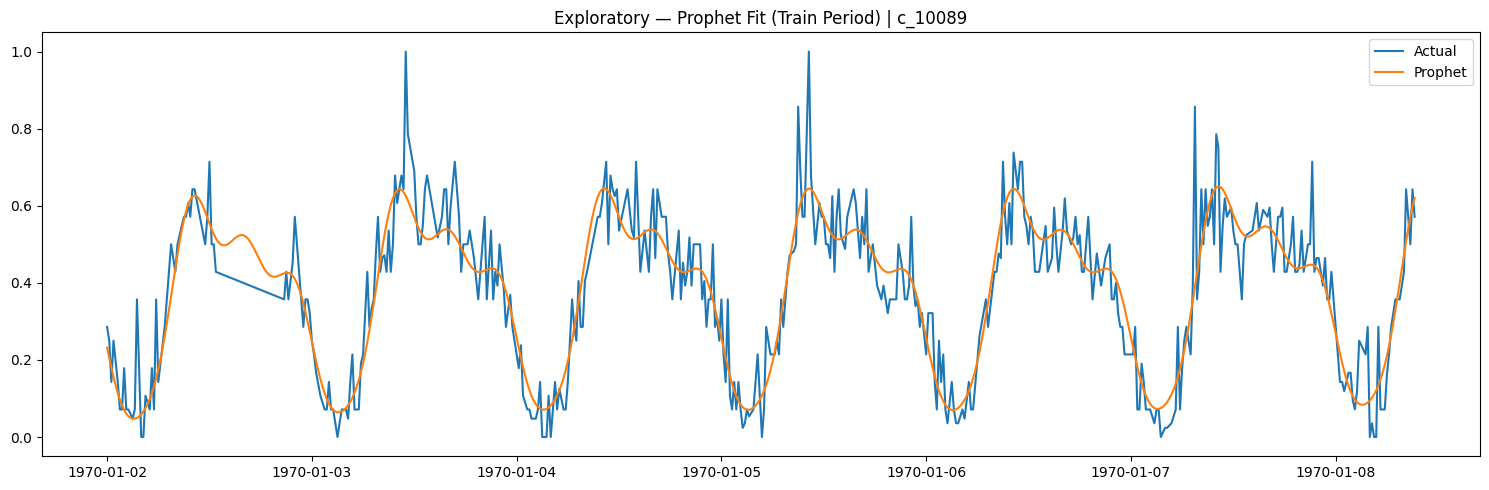

In [195]:
plt.figure(figsize=(15, 5))

plt.plot(
    sample_df["time_stamp"],
    sample_df["cpu_scaled"],
    label="Actual"
)
plt.plot(
    sample_df["time_stamp"],
    sample_df["prophet_pred"],
    label="Prophet"
)
plt.title(
    f"Exploratory — Prophet Fit (Train Period) | {sample_cid}"
)
plt.legend()
plt.tight_layout()
plt.show()


In [196]:
# Unpack cached inference outputs from primary evaluation.
# Day 2 arrays are available for supplementary analysis below.
_inference = inference_results[target_cid]

train_container = _inference.train_container
val_container = _inference.val_container
prophet_train = _inference.prophet_train
prophet_model = _inference.prophet_model
forecast = _inference.forecast
train_forecast = _inference.train_forecast
residual_input = _inference.residual_input
X_input = _inference.X_input
day1_residual_scaled = _inference.day1_residual_scaled
day1_residual = _inference.day1_residual
day1_prophet = _inference.day1_prophet
day1_final_scaled = _inference.day1_final_scaled
day2_input_residuals = _inference.day2_input_residuals
X_day2 = _inference.X_day2
day2_residual_scaled = _inference.day2_residual_scaled
day2_residual = _inference.day2_residual
day2_prophet = _inference.day2_prophet
available_len = _inference.available_len
day2_final_scaled = _inference.day2_final_scaled
actual_day1_scaled = _inference.actual_day1_scaled
actual_day2_scaled = _inference.actual_day2_scaled
scaler = _inference.scaler
day1_final_real = _inference.day1_final_real
actual_day1_real = _inference.actual_day1_real
prophet_day1_real = _inference.prophet_day1_real
day2_final_real = _inference.day2_final_real
actual_day2_real = _inference.actual_day2_real
prophet_day2_real = _inference.prophet_day2_real


In [197]:
val_container.head()


,container_id,time_stamp,cpu_util_percent,cpu_usage,machine_id,mem_util_percent,cpi,mem_gps,mpki,net_in,net_out,disk_io_percent,cpu,cpu_scaled,cpu_mean,cpu_std,cpu_max,cpu_min,hour,prophet_pred
308,c_10089,1970-01-08 09:30:00,13.000000,13.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13.000000,0.642857,0.377542,0.199226,1.0,0.0,9,0.637903
309,c_10089,1970-01-08 09:45:00,13.000000,13.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13.000000,0.642857,0.377542,0.199226,1.0,0.0,9,0.650653
310,c_10089,1970-01-08 10:00:00,13.666667,13.666667,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13.666667,0.690476,0.377542,0.199226,1.0,0.0,10,0.658364
311,c_10089,1970-01-08 10:15:00,12.500000,12.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12.500000,0.607143,0.377542,0.199226,1.0,0.0,10,0.661147
312,c_10089,1970-01-08 10:30:00,14.000000,14.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14.000000,0.714286,0.377542,0.199226,1.0,0.0,10,0.659308


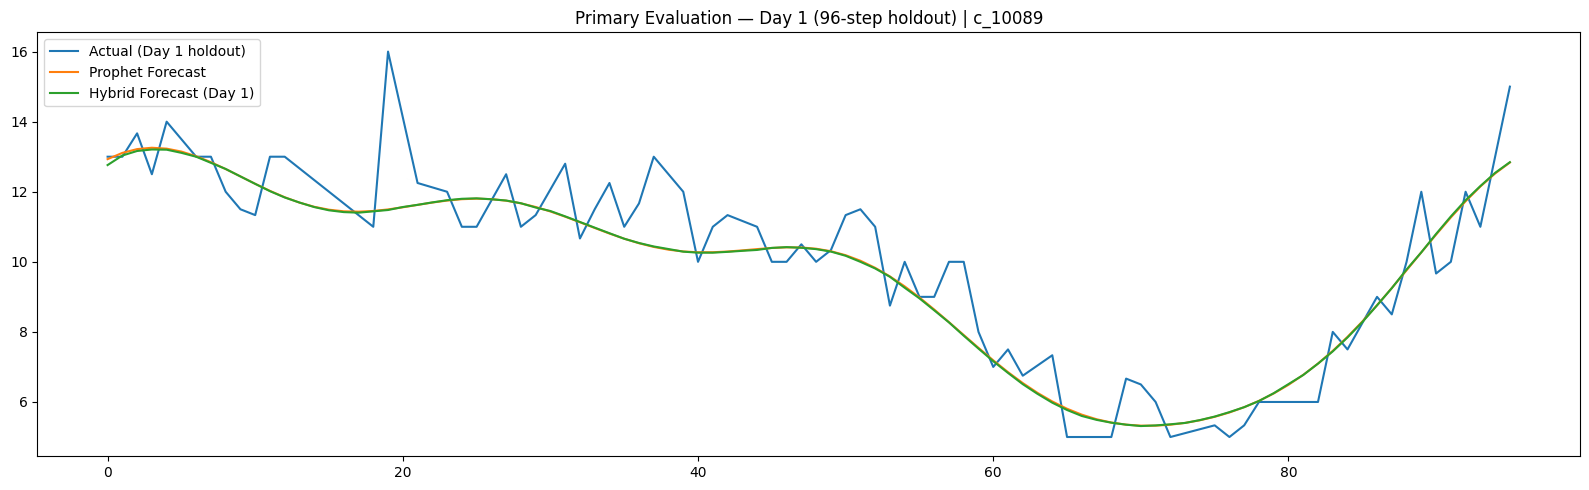

In [198]:
plt.figure(figsize=(16, 5))

plt.plot(
    actual_day1_real,
    label="Actual (Day 1 holdout)"
)
plt.plot(
    prophet_day1_real,
    label="Prophet Forecast"
)
plt.plot(
    day1_final_real,
    label="Hybrid Forecast (Day 1)"
)
plt.title(
    f"Primary Evaluation — Day 1 (96-step holdout) | {target_cid}"
)
plt.legend()
plt.tight_layout()
plt.show()


## Supplementary Evaluation (Day 2 — Recursive Extension)

Day 2 forecast slides the GRU input window: drops the first 96 residuals,
appends **predicted** Day 1 residuals, and predicts the next 96 steps.

This recursive extension illustrates error compounding beyond the primary
96-step horizon. **Day 2 metrics are not included in `evaluation_df` or
`evaluation_summary`.**

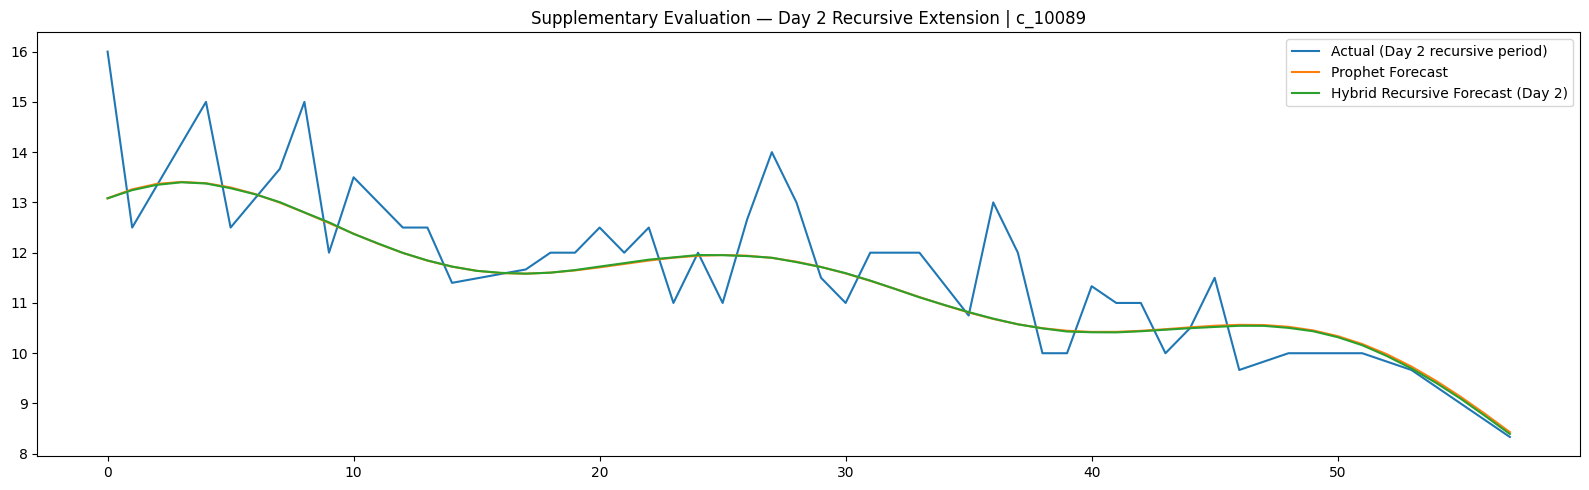

In [199]:
plt.figure(figsize=(16, 5))

plt.plot(
    actual_day2_real,
    label="Actual (Day 2 recursive period)"
)
plt.plot(
    prophet_day2_real,
    label="Prophet Forecast"
)
plt.plot(
    day2_final_real,
    label="Hybrid Recursive Forecast (Day 2)"
)
plt.title(
    f"Supplementary Evaluation — Day 2 Recursive Extension | {target_cid}"
)
plt.legend()
plt.tight_layout()
plt.show()


In [200]:
print("=" * 60)
print("DEMO — Primary Evaluation Cross-Check (Day 1)")
print("=" * 60)

day1_mae = mean_absolute_error(
    actual_day1_real,
    day1_final_real,
)
day1_rmse = np.sqrt(
    mean_squared_error(
        actual_day1_real,
        day1_final_real,
    )
)

demo_eval_row = evaluation_df.loc[
    evaluation_df["container_id"] == target_cid
].iloc[0]

print(f"Sample container: {target_cid}")
print(f"  Day 1 MAE  (recomputed) : {day1_mae:.4f}")
print(f"  Day 1 RMSE (recomputed) : {day1_rmse:.4f}")
print(f"  Day 1 MAE  (evaluation_df): {demo_eval_row['day1_mae']:.4f}")
print(f"  Day 1 RMSE (evaluation_df): {demo_eval_row['day1_rmse']:.4f}")

if "day1_mape" in demo_eval_row.index:
    demo_day1_mape = demo_eval_row["day1_mape"]
else:
    demo_day1_mape = compute_day1_mape(
        actual_day1_real,
        day1_final_real,
    )
    print(
        "  Note: evaluation_df is stale — re-run Primary Evaluation "
        "to populate day1_mape for all containers."
    )

print(f"  Day 1 MAPE (evaluation_df): {demo_day1_mape:.4f}")

print()
print("=" * 60)
print("SUPPLEMENTARY EVALUATION — Day 2 Recursive Extension")
print("=" * 60)
print("Not included in evaluation_df or evaluation_summary.")
print()

day2_mae = mean_absolute_error(
    actual_day2_real,
    day2_final_real,
)
day2_rmse = np.sqrt(
    mean_squared_error(
        actual_day2_real,
        day2_final_real,
    )
)

print(f"Sample container: {target_cid}")
print(f"  Day 2 MAE  (recursive) : {day2_mae:.4f}")
print(f"  Day 2 RMSE (recursive) : {day2_rmse:.4f}")


DEMO — Primary Evaluation Cross-Check (Day 1)
Sample container: c_10089
  Day 1 MAE  (recomputed) : 0.7674
  Day 1 RMSE (recomputed) : 1.0241
  Day 1 MAE  (evaluation_df): 0.7674
  Day 1 RMSE (evaluation_df): 1.0241
  Day 1 MAPE (evaluation_df): 7.7327

SUPPLEMENTARY EVALUATION — Day 2 Recursive Extension
Not included in evaluation_df or evaluation_summary.

Sample container: c_10089
  Day 2 MAE  (recursive) : 0.6459
  Day 2 RMSE (recursive) : 0.8836


## Exploratory Plots

Diagnostic visuals for residual behaviour during training.
Not part of primary or supplementary evaluation metrics.


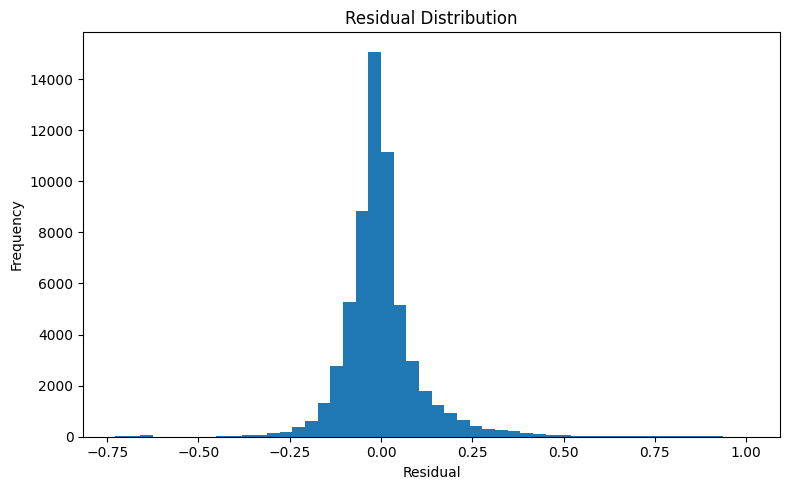

In [201]:
plt.figure(figsize=(8, 5))

plt.hist(
    train_residual_df["residual"],
    bins=50
)
plt.title("Residual Distribution")
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


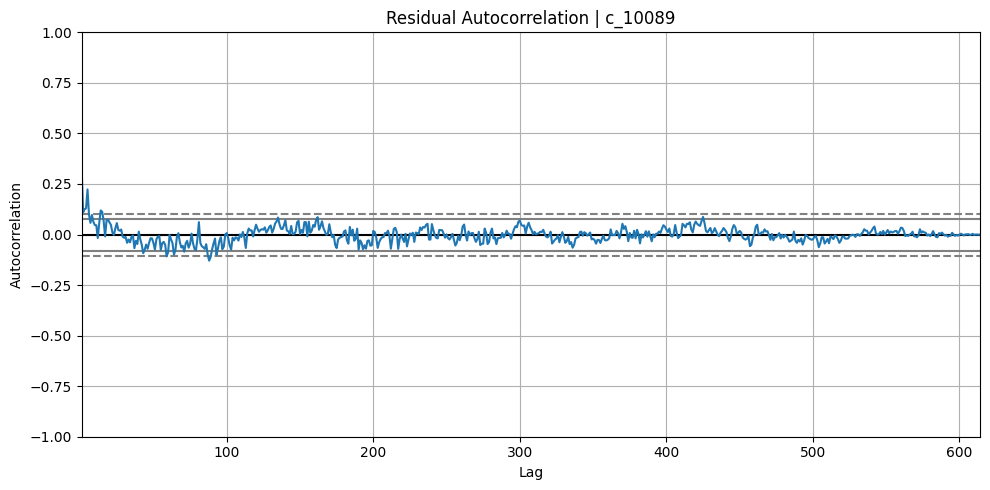

In [202]:
from pandas.plotting import autocorrelation_plot

plt.figure(figsize=(10, 5))
autocorrelation_plot(
    sample_df["residual"]
)
plt.title(
    f"Residual Autocorrelation | {sample_cid}"
)
plt.tight_layout()
plt.show()


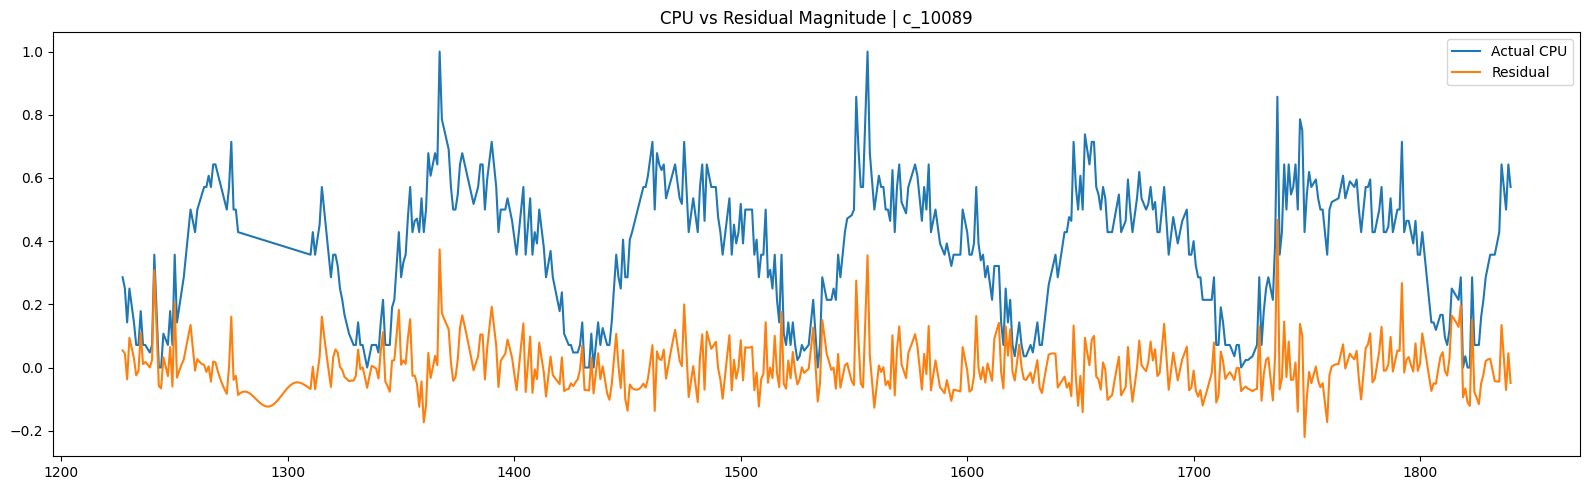

In [203]:
plt.figure(figsize=(16, 5))

plt.plot(
    sample_df["cpu_scaled"],
    label="Actual CPU"
)
plt.plot(
    sample_df["residual"],
    label="Residual"
)
plt.legend()
plt.title(
    f"CPU vs Residual Magnitude | {sample_cid}"
)
plt.tight_layout()
plt.show()
